# Deep Image Prior in DeepInverse: from Demo to Serious Experimentation

This notebook turns the basic DeepInverse DIP demo into a more serious experimental notebook.

## Goals

We will:
1. reproduce the DeepInverse DIP setup,
2. understand the optimization problem and architecture,
3. log optimization trajectories instead of only the final reconstruction,
4. sweep important architectural hyperparameters,
5. study early stopping and overfitting,
6. prepare the notebook so it can become the first component of a larger GitHub repo on self-supervised image reconstruction.

## Core DIP idea

Deep Image Prior solves:

\[
\min_\theta \|y - A f_\theta(z)\|^2
\]

where:
- \(x\) is the unknown clean image,
- \(A\) is the forward operator,
- \(y\) is the observed degraded measurement,
- \(f_\theta\) is an **untrained** convolutional decoder,
- \(z\) is a fixed random input.

The reconstruction is:

\[
\hat x = f_\theta(z)
\]

The surprising idea is that the **architecture itself** acts as an implicit prior. In practice, the network often fits natural image structure before fitting noise or artifacts, which is why **early stopping** is crucial.

## What we add beyond the stock demo

The original DeepInverse example is excellent for first contact, but for research we need more:

- metric curves across iterations,
- measurement consistency curves,
- architecture sweeps,
- corruption/operator sweeps,
- saved outputs and explicit observations.

This notebook is organized around those goals.

In [2]:
!pip install deepinv

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 986.9/986.9 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 27.2 MB/s eta 0:00:00


In [3]:
# If deepinv is not installed, uncomment the next line.
# !pip install deepinv

import copy
import math
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

import deepinv as dinv

## 1. Device and reproducibility

We first define the device and a global seed.

In [4]:
device = dinv.utils.get_freer_gpu() if torch.cuda.is_available() else "cpu"
torch.manual_seed(0)
np.random.seed(0)

print("Device:", device)

Device: cpu


## 2. Metric helpers and plotting utilities

We define:
- PSNR,
- SSIM,
- measurement consistency,
- curve plotting,
- image display helpers.

The main additional metric for inverse problems is **measurement consistency**:

\[
\|A\hat x - y\|^2
\]

This is important because a reconstruction may look visually good but still violate the physics.

In [5]:
psnr_metric = dinv.metric.PSNR()

try:
    from skimage.metrics import structural_similarity as skimage_ssim
    HAS_SKIMAGE = True
except Exception:
    HAS_SKIMAGE = False
    print("skimage not available: using a crude SSIM fallback.")


def to_numpy_img(x):
    x = x.detach().clamp(0, 1).cpu()
    if x.ndim == 4:
        x = x[0]
    x = x.permute(1, 2, 0).numpy()
    return x


def compute_psnr(x_gt, x_hat):
    return float(psnr_metric(x_gt, x_hat).item())


def compute_ssim(x_gt, x_hat):
    x1 = to_numpy_img(x_gt)
    x2 = to_numpy_img(x_hat)

    if HAS_SKIMAGE:
        if x1.shape[-1] == 1:
            return float(skimage_ssim(x1[..., 0], x2[..., 0], data_range=1.0))
        return float(skimage_ssim(x1, x2, data_range=1.0, channel_axis=-1))

    mse = ((x1 - x2) ** 2).mean()
    return float(1.0 / (1.0 + mse))


def measurement_consistency(x_hat, y, physics):
    resid = physics.A(x_hat) - y
    return float(resid.pow(2).mean().item())


def plot_metric_curves(history, title="DIP optimization curves"):
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    axes[0].plot(history["iter"], history["loss"], label="train loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Iteration")
    axes[0].grid(True)

    axes[1].plot(history["iter"], history["psnr"], label="PSNR")
    axes[1].set_title("PSNR")
    axes[1].set_xlabel("Iteration")
    axes[1].grid(True)

    axes[2].plot(history["iter"], history["ssim"], label="SSIM")
    axes[2].set_title("SSIM")
    axes[2].set_xlabel("Iteration")
    axes[2].grid(True)

    axes[3].plot(history["iter"], history["meas_consistency"], label="||Ax-y||^2")
    axes[3].set_title("Measurement consistency")
    axes[3].set_xlabel("Iteration")
    axes[3].grid(True)

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def show_reconstruction_triplet(x, y, x_hat, title="Reconstruction"):
    dinv.utils.plotting.plot(
        {
            "Measurement": y,
            "Ground Truth": x,
            "Reconstruction": x_hat,
        },
        suptitle=title,
    )

## 3. Load one test image

We start from a single image, exactly as in the DIP spirit.

For early experimentation, a small image is fine. Later, you should move to a more systematic dataset subset.

OR use local image

Loaded from: local image: /content/image (1).png
Image shape: (1, 3, 256, 256)


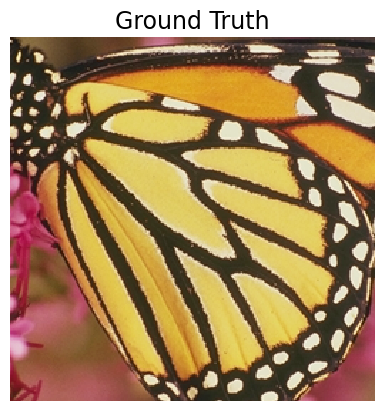

In [20]:
from pathlib import Path

# ----------------------------
# Image source configuration
# ----------------------------
USE_LOCAL_IMAGE = True
LOCAL_IMAGE_PATH = "/content/image (1).png"   # change this if USE_LOCAL_IMAGE=True

USE_DEEPINV_EXAMPLE = False               # simplest default
DEEPINV_EXAMPLE_NAME = "messi.jpg"

USE_URL_IMAGE = False
URL_IMAGE = "https://huggingface.co/datasets/deepinv/images/resolve/main/DIV2K/DIV2K_valid_HR/0801.png"

img_size = 256
grayscale = False

# ----------------------------
# Load image
# ----------------------------
if USE_LOCAL_IMAGE:
    local_path = Path(LOCAL_IMAGE_PATH)
    if not local_path.exists():
        raise FileNotFoundError(f"Local image not found: {local_path.resolve()}")
    x = dinv.utils.load_image(
        path=str(local_path),
        img_size=img_size,
        grayscale=grayscale,
    ).to(device)
    source_used = f"local image: {local_path}"

elif USE_DEEPINV_EXAMPLE:
    x = dinv.utils.load_example(
        DEEPINV_EXAMPLE_NAME,
        img_size=img_size,
    ).to(device)
    source_used = f"deepinv example: {DEEPINV_EXAMPLE_NAME}"

elif USE_URL_IMAGE:
    x = dinv.utils.load_url_image(
        url=URL_IMAGE,
        img_size=img_size,
        grayscale=grayscale,
    ).to(device)
    source_used = f"url image: {URL_IMAGE}"

else:
    raise ValueError("Enable one image source: local, deepinv example, or URL.")

print("Loaded from:", source_used)
print("Image shape:", tuple(x.shape))
dinv.utils.plotting.plot({"Ground Truth": x}, figsize=(4, 4))

## 4. Define the inverse problem

We begin with **inpainting + Gaussian noise**, just like the basic demo.

Forward model:
- random inpainting mask,
- additive Gaussian noise.

Mathematically:

\[
y = A(x) + \varepsilon
\]

where \(A\) drops pixels according to the inpainting mask.

Measurement shape: (1, 3, 256, 256)


/usr/local/lib/python3.12/dist-packages/deepinv/utils/plotting.py:408: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(top=0.75)


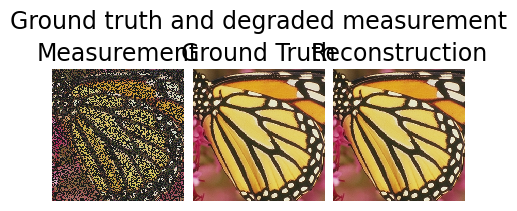

In [21]:
mask = 0.5
sigma = 0.05

physics = dinv.physics.Inpainting(
    mask=mask,
    img_size=x.shape[1:],
    device=device,
)
physics.noise_model = dinv.physics.GaussianNoise(sigma=sigma)

y = physics(x)

print("Measurement shape:", tuple(y.shape))
show_reconstruction_triplet(x, y, x, title="Ground truth and degraded measurement")

## 5. Baseline: naive adjoint reconstruction

Before running DIP, compare with the simplest baseline:
\[
\hat x_{\text{adjoint}} = A^\top y
\]

For inpainting, this typically just fills missing entries trivially and does not recover lost content meaningfully.

Adjoint PSNR: 8.515378952026367
Adjoint SSIM: 0.19060958921909332
Adjoint measurement consistency: 0.0


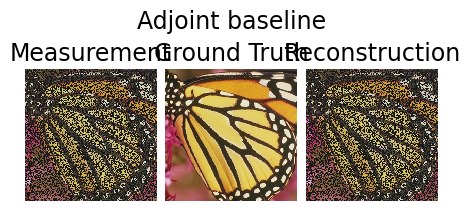

In [22]:
x_adjoint = physics.A_adjoint(y)

print("Adjoint PSNR:", compute_psnr(x, x_adjoint))
print("Adjoint SSIM:", compute_ssim(x, x_adjoint))
print("Adjoint measurement consistency:", measurement_consistency(x_adjoint, y, physics))

show_reconstruction_triplet(x, y, x_adjoint, title="Adjoint baseline")

## 6. Manual DIP implementation

This is the most important cell in the notebook.

Instead of relying only on the high-level DeepInverse wrapper, we implement the optimization loop manually so that we can:
- log trajectories,
- save snapshots,
- inspect overfitting,
- run sweeps.

We use `deepinv.models.ConvDecoder`, which is the recommended DIP backbone in the DeepInverse example.

We are not telling the network:

match the clean image.

We are telling it:

produce an image whose forward projection matches what was measured.

In [23]:
def run_dip_manual(
    x,
    y,
    physics,
    channels=64,
    in_size=(2, 2),
    iterations=1000,
    lr=1e-2,
    log_every=10,
    save_all_preds=False,
    seed=0,
):
    torch.manual_seed(seed)
    np.random.seed(seed)

    device = x.device
    img_size = x.shape[1:]

    backbone = dinv.models.ConvDecoder(
        img_size=img_size,
        in_size=list(in_size),
        channels=channels,
    ).to(device)

    z = torch.randn((1, channels, in_size[0], in_size[1]), device=device)
    optimizer = torch.optim.Adam(backbone.parameters(), lr=lr)

    history = {
        "iter": [],
        "loss": [],
        "psnr": [],
        "ssim": [],
        "meas_consistency": [],
    }

    snapshots = []
    best_psnr = -float("inf")
    best_x = None
    best_iter = -1

    for it in range(1, iterations + 1):
        optimizer.zero_grad()

        x_hat = backbone(z)
        loss = F.mse_loss(physics.A(x_hat), y)

        loss.backward()
        optimizer.step()

        if (it % log_every == 0) or (it == 1) or (it == iterations):
            with torch.no_grad():
                x_hat_eval = backbone(z).clamp(0, 1)

                psnr_val = compute_psnr(x, x_hat_eval)
                ssim_val = compute_ssim(x, x_hat_eval)
                mc_val = measurement_consistency(x_hat_eval, y, physics)

                history["iter"].append(it)
                history["loss"].append(float(loss.item()))
                history["psnr"].append(psnr_val)
                history["ssim"].append(ssim_val)
                history["meas_consistency"].append(mc_val)

                if save_all_preds:
                    snapshots.append((it, x_hat_eval.detach().cpu()))

                if psnr_val > best_psnr:
                    best_psnr = psnr_val
                    best_x = x_hat_eval.detach().clone()
                    best_iter = it

    final_x = backbone(z).detach().clamp(0, 1)

    print(f"Best PSNR:  {best_psnr:.3f} dB at iteration {best_iter}")
    print(f"Final PSNR: {compute_psnr(x, final_x):.3f} dB")

    return {
        "best_x": best_x,
        "final_x": final_x,
        "history": history,
        "snapshots": snapshots,
        "backbone": backbone,
        "best_iter": best_iter,
        "best_psnr": best_psnr,
        "config": {
            "channels": channels,
            "in_size": in_size,
            "iterations": iterations,
            "lr": lr,
            "log_every": log_every,
            "seed": seed,
        },
    }

## 7. First serious DIP run

We now run DIP for many more iterations than the stock demo so we can actually observe:
- improvement,
- peak reconstruction,
- and late-stage overfitting.

### What to watch for
A typical DIP behavior is:
- measurement consistency keeps improving,
- but PSNR peaks earlier,
- which means better measurement fit does **not** necessarily mean better reconstruction.

In [24]:
dip_run = run_dip_manual(
    x=x,
    y=y,
    physics=physics,
    channels=64,
    in_size=(2, 2),
    iterations=1000,
    lr=1e-2,
    log_every=10,
    save_all_preds=False,
    seed=0,
)

Best PSNR:  21.328 dB at iteration 1000
Final PSNR: 21.328 dB


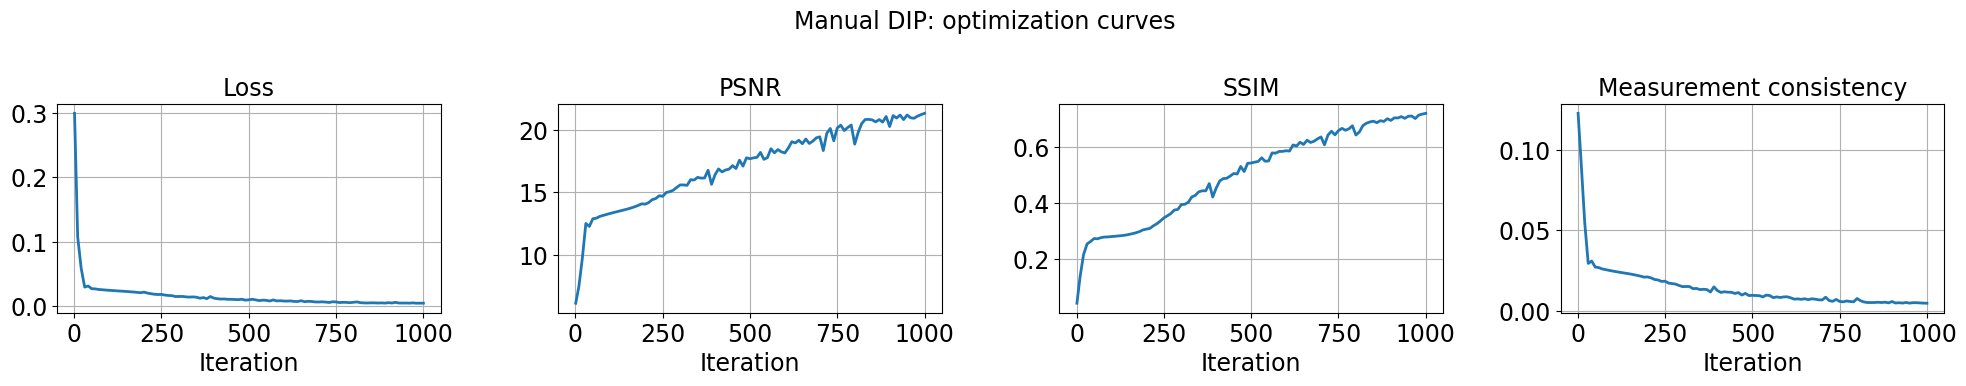

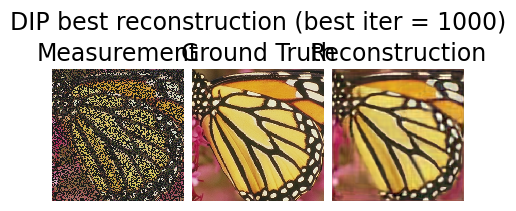

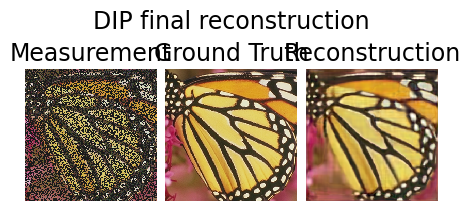

In [25]:
plot_metric_curves(dip_run["history"], title="Manual DIP: optimization curves")

show_reconstruction_triplet(
    x,
    y,
    dip_run["best_x"],
    title=f"DIP best reconstruction (best iter = {dip_run['best_iter']})",
)

show_reconstruction_triplet(
    x,
    y,
    dip_run["final_x"],
    title="DIP final reconstruction",
)

## 8. Compare against the stock DeepInverse `DeepImagePrior` wrapper

This sanity-check ensures our manual implementation behaves similarly to the official wrapper.

100%|██████████| 100/100 [01:25<00:00,  1.17it/s]


Reference wrapper PSNR: 13.411580085754395
Reference wrapper SSIM: 0.29054585099220276


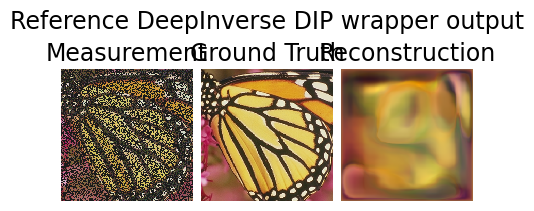

In [29]:
iterations_ref = 100
lr_ref = 1e-2
channels_ref = 64
in_size_ref = [2, 2]

backbone_ref = dinv.models.ConvDecoder(
    img_size=x.shape[1:],      # output image size for the decoder
    in_size=in_size_ref,
    channels=channels_ref,
).to(device)

f_ref = dinv.models.DeepImagePrior(
    backbone_ref,
    img_size=[channels_ref] + in_size_ref,   # latent input size for the wrapper
    learning_rate=lr_ref,
    iterations=iterations_ref,
    verbose=True,
).to(device)

dip_ref = f_ref(y, physics).detach().clamp(0, 1)

print("Reference wrapper PSNR:", compute_psnr(x, dip_ref))
print("Reference wrapper SSIM:", compute_ssim(x, dip_ref))
show_reconstruction_triplet(x, y, dip_ref, title="Reference DeepInverse DIP wrapper output")

## 9. Experiment A: architecture sweep over `in_size`

This is one of the most informative sweeps.

The demo fixes `in_size=[2,2]`, but that choice is a strong architectural bias. A smaller latent spatial size forces the network to synthesize the image more hierarchically, while a larger latent spatial size may allow finer detail earlier but can also make overfitting easier.

### Hypothesis
- smaller `in_size` may act as a stronger prior,
- larger `in_size` may improve early sharpness but overfit faster.

In [ ]:
in_size_list = [(1, 1), (2, 2), (4, 4), (8, 8)]
results_insize = []

for ins in in_size_list:
    print(f"\nRunning in_size={ins}")
    out = run_dip_manual(
        x=x,
        y=y,
        physics=physics,
        channels=64,
        in_size=ins,
        iterations=1000,
        lr=1e-2,
        log_every=20,
        seed=0,
    )
    results_insize.append({
        "in_size": ins,
        "best_psnr": out["best_psnr"],
        "best_iter": out["best_iter"],
        "final_psnr": compute_psnr(x, out["final_x"]),
        "best_x": out["best_x"],
        "history": out["history"],
    })

print("\nSummary:")
for r in results_insize:
    print(
        f"in_size={r['in_size']}, "
        f"best_psnr={r['best_psnr']:.3f}, "
        f"best_iter={r['best_iter']}, "
        f"final_psnr={r['final_psnr']:.3f}"
    )


Running in_size=(1, 1)


In [ ]:
fig, axes = plt.subplots(1, len(results_insize), figsize=(4 * len(results_insize), 4))
if len(results_insize) == 1:
    axes = [axes]

for ax, r in zip(axes, results_insize):
    img = to_numpy_img(r["best_x"])
    ax.imshow(img.squeeze() if img.shape[-1] == 1 else img)
    ax.set_title(f"in_size={r['in_size']}\nPSNR={r['best_psnr']:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 4))
for r in results_insize:
    plt.plot(r["history"]["iter"], r["history"]["psnr"], label=f"in_size={r['in_size']}")
plt.xlabel("Iteration")
plt.ylabel("PSNR")
plt.title("PSNR trajectories for different latent spatial sizes")
plt.grid(True)
plt.legend()
plt.show()

### Notes to write down
As you inspect the results, answer:
1. Which `in_size` gives the highest peak PSNR?
2. Which one overfits fastest?
3. Does smaller `in_size` produce smoother but more stable reconstructions?
4. Does larger `in_size` improve detail but shrink the safe early-stopping window?

## 10. Experiment B: channel sweep

The stock demo fixes `channels=64`. We now vary the decoder capacity.

### Hypothesis
Increasing channels increases model capacity, but capacity may help reconstruction only up to a point; beyond that, it may mainly accelerate overfitting.

In [ ]:
channel_list = [16, 32, 64, 128]
results_channels = []

for ch in channel_list:
    print(f"\nRunning channels={ch}")
    out = run_dip_manual(
        x=x,
        y=y,
        physics=physics,
        channels=ch,
        in_size=(2, 2),
        iterations=1000,
        lr=1e-2,
        log_every=20,
        seed=0,
    )
    results_channels.append({
        "channels": ch,
        "best_psnr": out["best_psnr"],
        "best_iter": out["best_iter"],
        "final_psnr": compute_psnr(x, out["final_x"]),
        "best_x": out["best_x"],
        "history": out["history"],
    })

print("\nSummary:")
for r in results_channels:
    print(
        f"channels={r['channels']}, "
        f"best_psnr={r['best_psnr']:.3f}, "
        f"best_iter={r['best_iter']}, "
        f"final_psnr={r['final_psnr']:.3f}"
    )

In [ ]:
fig, axes = plt.subplots(1, len(results_channels), figsize=(4 * len(results_channels), 4))
if len(results_channels) == 1:
    axes = [axes]

for ax, r in zip(axes, results_channels):
    img = to_numpy_img(r["best_x"])
    ax.imshow(img.squeeze() if img.shape[-1] == 1 else img)
    ax.set_title(f"ch={r['channels']}\nPSNR={r['best_psnr']:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(7, 4))
for r in results_channels:
    plt.plot(r["history"]["iter"], r["history"]["psnr"], label=f"channels={r['channels']}")
plt.xlabel("Iteration")
plt.ylabel("PSNR")
plt.title("PSNR trajectories for different channel counts")
plt.grid(True)
plt.legend()
plt.show()

### Notes to write down
As you inspect the results, answer:
1. Does best PSNR improve with channels?
2. Does the best iteration move earlier as channels increase?
3. Is there a point where more channels mostly hurt stability?

## 11. Experiment C: visualize optimization dynamics

This is one of the most intuitive DIP analyses.

We save intermediate reconstructions and inspect how the network output evolves across optimization.

### What to watch for
- early coarse structures,
- progressive sharpening,
- possible late-stage artifact/noise fitting.

In [ ]:
dip_snap = run_dip_manual(
    x=x,
    y=y,
    physics=physics,
    channels=64,
    in_size=(2, 2),
    iterations=1000,
    lr=1e-2,
    log_every=50,
    save_all_preds=True,
    seed=0,
)

In [ ]:
num_show = min(8, len(dip_snap["snapshots"]))
fig, axes = plt.subplots(1, num_show, figsize=(4 * num_show, 4))
if num_show == 1:
    axes = [axes]

for ax, (it, xhat_cpu) in zip(axes, dip_snap["snapshots"][:num_show]):
    img = to_numpy_img(xhat_cpu.to(device))
    ax.imshow(img.squeeze() if img.shape[-1] == 1 else img)
    ax.set_title(f"iter={it}")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 12. Save results

This makes the notebook useful for a future GitHub repo or portfolio.

You should save:
- metric trajectories,
- best/final reconstructions,
- sweep summaries,
- and qualitative figures.

In [ ]:
results_dir = Path("results_dip")
results_dir.mkdir(exist_ok=True)

torch.save(dip_run["history"], results_dir / "dip_history.pt")
torch.save(dip_run["best_x"].cpu(), results_dir / "dip_best_x.pt")
torch.save(dip_run["final_x"].cpu(), results_dir / "dip_final_x.pt")
torch.save(results_insize, results_dir / "dip_in_size_sweep.pt")
torch.save(results_channels, results_dir / "dip_channel_sweep.pt")

print(f"Saved results to: {results_dir.resolve()}")

## 13. Optional extension: wrap sweep results into a small summary table

This is useful when turning experiments into notes or a report.

In [ ]:
import pandas as pd

df_insize = pd.DataFrame([
    {
        "in_size": str(r["in_size"]),
        "best_psnr": r["best_psnr"],
        "best_iter": r["best_iter"],
        "final_psnr": r["final_psnr"],
    }
    for r in results_insize
])

df_channels = pd.DataFrame([
    {
        "channels": r["channels"],
        "best_psnr": r["best_psnr"],
        "best_iter": r["best_iter"],
        "final_psnr": r["final_psnr"],
    }
    for r in results_channels
])

print("In-size sweep summary")
display(df_insize)

print("\nChannel sweep summary")
display(df_channels)

## 14. Serious observations to write after running this notebook

This section is intentionally left as a research log template.

### Observation log template

#### A. Optimization dynamics
- Does PSNR peak before measurement consistency stabilizes?
- Is the PSNR peak sharp or broad?
- How sensitive is the best iteration to random seed?

#### B. Latent spatial size (`in_size`)
- Does smaller latent size act like a stronger regularizer?
- Does larger latent size accelerate overfitting?
- Is there a best trade-off point?

#### C. Decoder capacity (`channels`)
- Is more capacity always helpful?
- Does it mainly improve best PSNR or mainly reduce the time to overfit?

#### D. Visual failure modes
- texture oversmoothing,
- late-stage noisy fit,
- checkerboard/upsampling artifacts,
- structure hallucination or edge thickening.

These observations will matter later when we compare DIP against other self-supervised methods like measurement splitting and equivariant imaging.

## 15. Suggested next experiments

Once this notebook is stable, the best next steps are:

1. **Change the physics**
   - Gaussian deblurring,
   - super-resolution,
   - denoising.

2. **Add early-stopping analysis**
   - best oracle stopping,
   - fixed iteration stopping,
   - simple measurement-based heuristics.

3. **Add seed sensitivity**
   - repeat each run for multiple seeds,
   - report mean and standard deviation.

4. **Add a hybrid regularizer later**
   - e.g. an equivariance term:
   \[
   \mathcal L(\theta)=\|y-Af_\theta(z)\|^2 + \lambda \mathcal L_{\text{equiv}}
   \]

That last step is where a real novelty path can begin.